# Plotting for Project 2

In [318]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from colormaps import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [319]:
np.random.seed(274)

# x0_map = {
#     "Simple1": np.array([[-2,2], [1, -2], [1.5, 1]]),
#     "Simple2": np.array([[2,2], [-1, -1], [3, 3]]),
#     "Simple3": np.array([[1,1,1], [-1, -3, -1], [2, 2, 1]]),
# }
# 10 random initializations in the range [-3, 3]
n_samples = 4
x0_map = {
    "Simple1": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 0),
    "Simple2": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 0),
    "Simple3": np.round(np.random.uniform(-3, 3, (n_samples, 3)), 0),
}

x_best_map = {
    "Simple1": np.array([2/3, 1/np.sqrt(3)]),
    "Simple2": np.array([1,1]),
    "Simple3": np.array([-1/np.sqrt(6), np.sqrt(2/3), -1/np.sqrt(6)]),
}

## Run All Algorithms

In [320]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

problems = [Simple1, Simple2, Simple3]
keys = {"Simple1": "simple1", "Simple2": "simple2", "Simple3": "simple3"}

results = {
    'abs_gd':     {'label': 'AP GD',          'x_hists': {}, 'f_hists': {}},
    'abs_lbfgs':  {'label': 'AP L-BFGS',     'x_hists': {}, 'f_hists': {}},
    'quad_gd':    {'label': 'QP GD',         'x_hists': {}, 'f_hists': {}},
    'quad_lbfgs': {'label': 'QP L-BFGS',    'x_hists': {}, 'f_hists': {}},
    'aug_gd':     {'label': 'AL GD',      'x_hists': {}, 'f_hists': {}},
    'aug_lbfgs':  {'label': 'AL L-BFGS', 'x_hists': {}, 'f_hists': {}},
}

n_max = 2000

for p_name in problems:
    for x0 in x0_map[p_name.__name__]:
        key = keys[p_name.__name__]
        k   = (p_name.__name__, tuple(x0))

        p = p_name()
        x_hist, _, f_hist, _, _, _, _ = penalty_l_bfgs(
            p.f, p.g, p.c, x0, n_max, p.count,
            strategy_config_map[key]['quadratic_penalty_l_bfgs'], penalty_mode='quadratic')
        results['quad_lbfgs']['x_hists'][k] = x_hist
        results['quad_lbfgs']['f_hists'][k] = f_hist

        p = p_name()
        x_hist, _, f_hist, _ = penalty_gradient_descent(
            p.f, p.g, p.c, x0, n_max, p.count,
            strategy_config_map[key]['quadratic_penalty_gradient_descent'], penalty_mode='quadratic')
        results['quad_gd']['x_hists'][k] = x_hist
        results['quad_gd']['f_hists'][k] = f_hist

        p = p_name()
        x_hist, _, f_hist, _, _, _, _ = penalty_l_bfgs(
            p.f, p.g, p.c, x0, n_max, p.count,
            strategy_config_map[key]['absolute_penalty_l_bfgs'], penalty_mode='absolute')
        results['abs_lbfgs']['x_hists'][k] = x_hist
        results['abs_lbfgs']['f_hists'][k] = f_hist

        p = p_name()
        x_hist, _, f_hist, _ = penalty_gradient_descent(
            p.f, p.g, p.c, x0, n_max, p.count,
            strategy_config_map[key]['absolute_penalty_gradient_descent'], penalty_mode='absolute')
        results['abs_gd']['x_hists'][k] = x_hist
        results['abs_gd']['f_hists'][k] = f_hist

        p = p_name()
        x_hist = augmented_lagrangian_gradient_descent(
            p.f, p.g, p.c, x0, n_max, p.count,
            strategy_config_map[key]['augmented_lagrangian_gradient_descent'])
        results['aug_gd']['x_hists'][k] = x_hist
        results['aug_gd']['f_hists'][k] = [p.f(x) for x in x_hist]

        p = p_name()
        x_hist = augmented_lagrangian_l_bfgs(
            p.f, p.g, p.c, x0, n_max, p.count,
            strategy_config_map[key]['augmented_lagrangian_l_bfgs'])
        results['aug_lbfgs']['x_hists'][k] = x_hist
        results['aug_lbfgs']['f_hists'][k] = [p.f(x) for x in x_hist]

print("All algorithms complete.")


All algorithms complete.


## Trajectories on Simple1

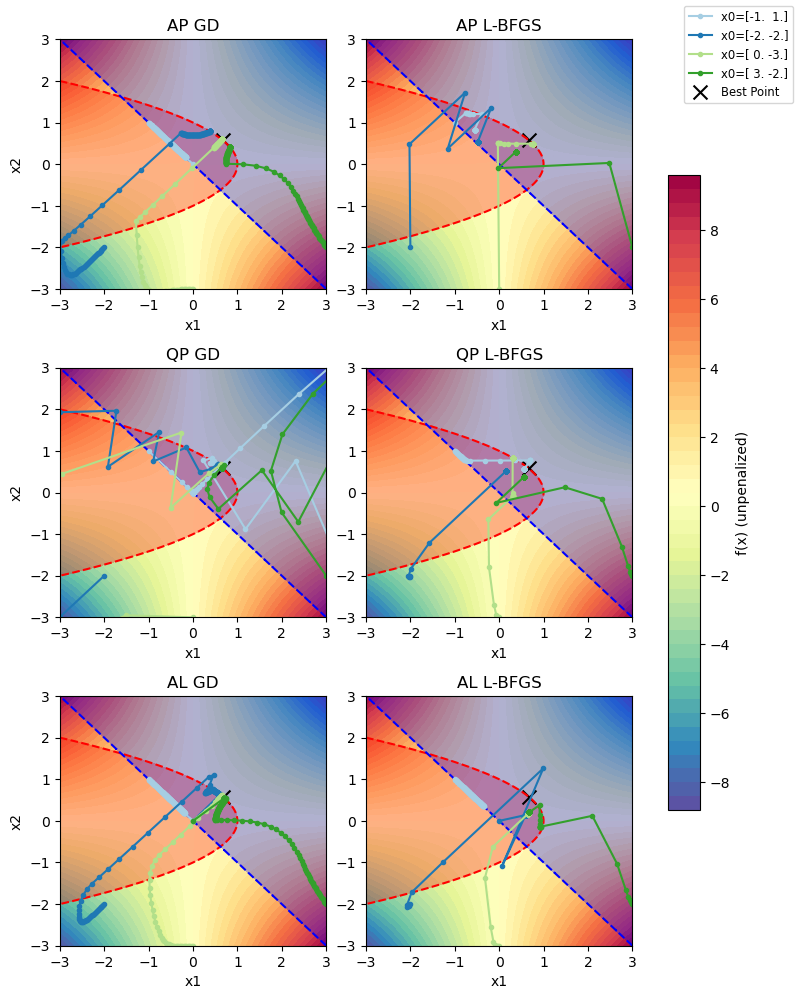

In [321]:
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([a, b])) for a, b in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten()

for ax, (algo, res) in zip(axes, results.items()):
    im = ax.contourf(X1, X2, Z, levels=50, cmap="Spectral_r")
    ax.set_title(f'{res["label"]}')
    ax.set_xlabel("x1"); 
    # leave out ylabel on right column to avoid overlap with legend
    ax.set_ylabel("x2" if ax in axes[::2] else "")
    ax.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
    ax.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)
    ax.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
    ax.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)
    for i, x0 in enumerate(x0_map["Simple1"]):
        xh = np.array(res["x_hists"][("Simple1", tuple(x0))])
        ax.plot(xh[:, 0], xh[:, 1], marker="o", markersize=3, label=f'x0={x0}', color=cmap["cbqual12"][i])
    x_best = x_best_map["Simple1"]
    ax.scatter(x_best[0], x_best[1], marker="x", color="black", s=100, label="Best Point")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    # tight layout to prevent label cutoff
    plt.tight_layout()
# make only one legend on the outside right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize='small')

fig.colorbar(im, ax=axes.tolist(), label="f(x) (unpenalized)", shrink=0.7)
# save figure with high dpi for better readability of legend and labels
plt.savefig("figs/trajectories_simple1.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Trajectories on Simple2

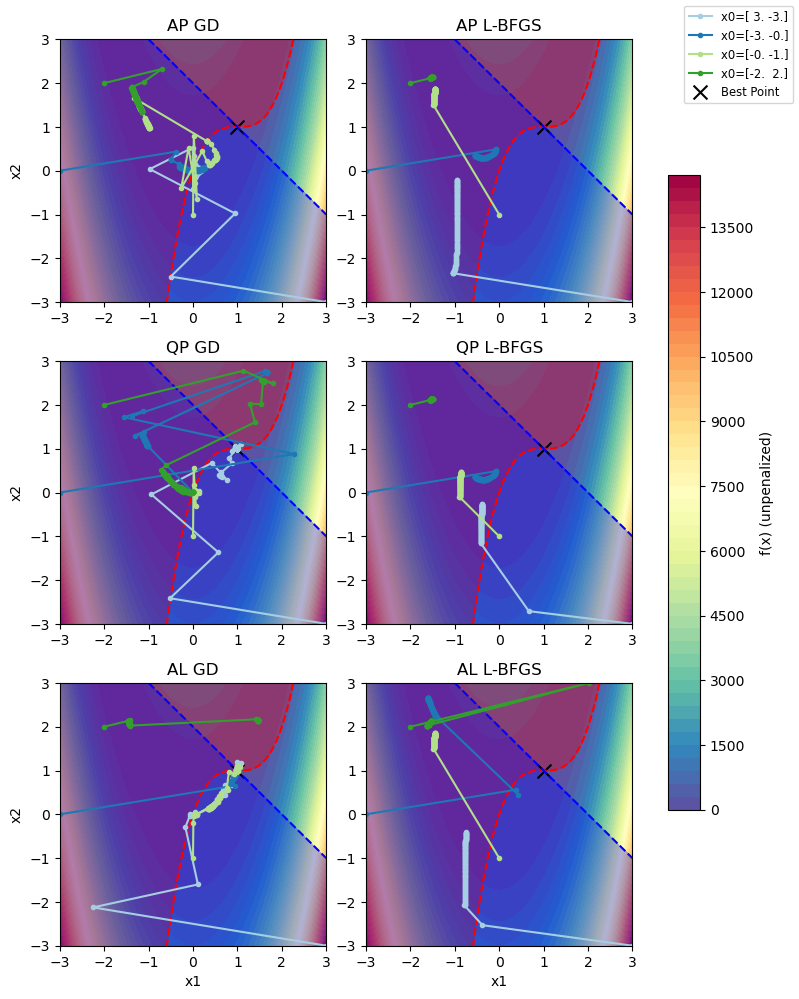

In [322]:
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([a, b])) for a, b in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 - 2

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten()

for ax, (algo, res) in zip(axes, results.items()):
    im = ax.contourf(X1, X2, Z, levels=50, cmap="Spectral_r")
    ax.set_title(f'{res["label"]}')
    # only set xlabel on bottom row to avoid overlap with legend and tight layout
    ax.set_xlabel("x1" if ax in axes[-2:] else "")
    # leave out ylabel on right column to avoid overlap with legend
    ax.set_ylabel("x2" if ax in axes[::2] else "")
    ax.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
    ax.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)
    ax.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
    ax.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)
    for i, x0 in enumerate(x0_map["Simple2"]):
        xh = np.array(res["x_hists"][("Simple2", tuple(x0))])
        ax.plot(xh[:, 0], xh[:, 1], marker="o", markersize=3, label=f'x0={x0}', color=cmap["cbqual12"][i])
    x_best = x_best_map["Simple2"]
    ax.scatter(x_best[0], x_best[1], marker="x", color="black", s=100, label="Best Point")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout()

# make only one legend on the outside right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize='small')

fig.colorbar(im, ax=axes.tolist(), label="f(x) (unpenalized)", shrink=0.7)

# save figure with high dpi for better readability of legend and labels
plt.savefig("figs/trajectories_simple2.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Objective Function and Max Constraint Violation (Simple2)

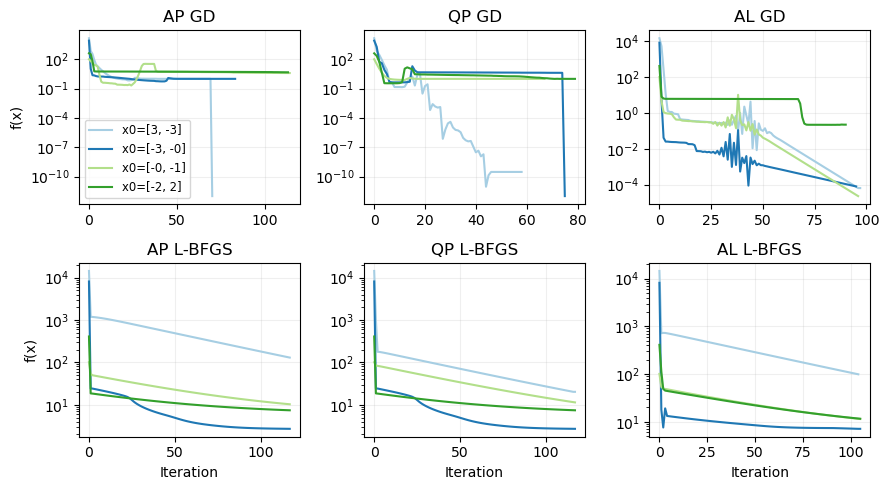

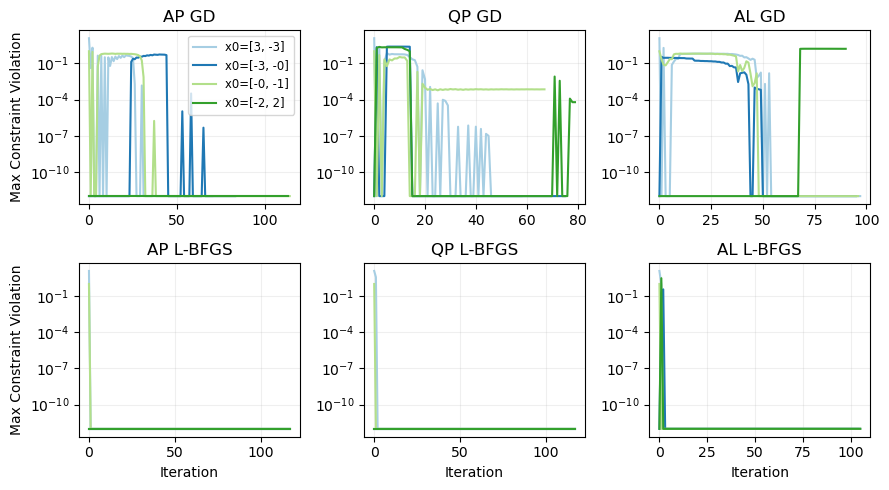

In [323]:
gd_algos    = ['abs_gd', 'quad_gd','aug_gd']
lbfgs_algos = ['abs_lbfgs', 'quad_lbfgs', 'aug_lbfgs']
row_groups  = [gd_algos, lbfgs_algos]

for metric, ylabel, title_suffix, get_vals in [
    ('f',  'f(x)',                   'Objective Function',        
     lambda res, k: [max(v, 1e-12) for v in res["f_hists"][k]]),
    ('c',  'Max Constraint Violation', 'Max Constraint Violation',
     lambda res, k: [max(1e-12, max((x[0]-1)**3 - x[1] + 1, x[0] + x[1] - 2))
                     for x in res["x_hists"][k]]),
]:
    fig, axes = plt.subplots(2, 3, figsize=(9, 5))
    for row, algos in enumerate(row_groups):
        for col, algo in enumerate(algos):
            ax  = axes[row, col]
            res = results[algo]
            for i, x0 in enumerate(x0_map["Simple2"]):
                k     = ("Simple2", tuple(x0))
                color = cmap["cbqual12"][i]
                lbl   = f'x0=[{x0[0]:.0f}, {x0[1]:.0f}]'
                ax.plot(get_vals(res, k), label=lbl, color=color)
            ax.set_yscale("log")
            if row == 1:
                ax.set_xlabel("Iteration"); 
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.set_title(f'{res["label"]}')
            # legend only on first plot
            if row == 0 and col == 0:
                ax.legend(fontsize='small'); 
            ax.grid(True, alpha=0.2)
    plt.tight_layout()
    # save figure with high dpi for better readability of legend and labels
    plt.savefig(f"figs/{title_suffix.lower().replace(' ', '_')}_simple2.pdf", dpi=300, bbox_inches='tight')
    plt.show()


## Feasibility Rates

In [324]:
import json
import pandas as pd
from IPython.display import display, HTML

with open("hypersearch_results/all_results.json") as f:
    hyper = json.load(f)

algo_keys = [
    ('quad_gd',    'quadratic_penalty_gradient_descent',    'QP GD'),
    ('quad_lbfgs', 'quadratic_penalty_l_bfgs',              'QP L-BFGS'),
    ('abs_gd',     'absolute_penalty_gradient_descent',     'AP GD'),
    ('abs_lbfgs',  'absolute_penalty_l_bfgs',               'AP L-BFGS'),
    ('aug_gd',     'augmented_lagrangian_gradient_descent', 'AL GD'),
    ('aug_lbfgs',  'augmented_lagrangian_l_bfgs',           'AL L-BFGS'),
]
problems = ['simple1', 'simple2', 'simple3', 'secret1', 'secret2']

rows = {}
for _, algo_key, label in algo_keys:
    row = {}
    for prob in problems:
        entry = hyper.get(prob, {}).get(algo_key)
        row[prob] = entry['feasibility_rate'] * 100 if entry else None
    rows[label] = row

df = pd.DataFrame(rows, index=problems).T
df.columns = [c.replace('simple', 'Simple ').replace('secret', 'Secret ').title() for c in df.columns]

def color_cell(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return 'color: gray'
    return 'color: green; font-weight: bold' if val >= 95 else 'color: red; font-weight: bold'

def fmt(val):
    return f'{val:.1f}%' if val is not None and not (isinstance(val, float) and pd.isna(val)) else '—'

styled = df.style.applymap(color_cell).format(fmt)
display(styled)

# LaTeX export
latex_lines = []
cols = list(df.columns)
latex_lines.append(r'\begin{table}[h]')
latex_lines.append(r'\centering')
latex_lines.append(r'\begin{tabular}{l' + 'r' * len(cols) + '}')
latex_lines.append(r'\toprule')
latex_lines.append('Algorithm & ' + ' & '.join(cols) + r' \\')
latex_lines.append(r'\midrule')
for algo, row in df.iterrows():
    cells = []
    for val in row:
        if val is None or (isinstance(val, float) and pd.isna(val)):
            cells.append('—')
        elif val >= 95:
            cells.append(r'\textcolor{green!60!black}{' + f'{val:.1f}\%' + '}')
        else:
            cells.append(r'\textcolor{red}{' + f'{val:.1f}\%' + '}')
    latex_lines.append(algo + ' & ' + ' & '.join(cells) + r' \\')
latex_lines.append(r'\bottomrule')
latex_lines.append(r'\end{tabular}')
latex_lines.append(r'\caption{Feasibility rates (\%) across problems and algorithms. Green: $\geq$95\%, Red: $<$95\%.}')
latex_lines.append(r'\label{tab:feasibility}')
latex_lines.append(r'\end{table}')
print('\n'.join(latex_lines))


/var/folders/nr/mlg2d__j0jn5q5ysp6ywyyh40000gn/T/ipykernel_25495/865700558.py:37: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df.style.applymap(color_cell).format(fmt)


,Simple 1,Simple 2,Simple 3,Secret 1,Secret 2
QP GD,48.5%,65.5%,67.5%,—,—
QP L-BFGS,99.5%,86.5%,100.0%,—,—
AP GD,100.0%,100.0%,100.0%,—,—
AP L-BFGS,97.5%,94.0%,100.0%,—,—
AL GD,100.0%,87.0%,83.5%,—,—
AL L-BFGS,100.0%,94.5%,100.0%,—,—


\begin{table}[h]
\centering
\begin{tabular}{lrrrrr}
\toprule
Algorithm & Simple 1 & Simple 2 & Simple 3 & Secret 1 & Secret 2 \\
\midrule
QP GD & \textcolor{red}{48.5\%} & \textcolor{red}{65.5\%} & \textcolor{red}{67.5\%} & — & — \\
QP L-BFGS & \textcolor{green!60!black}{99.5\%} & \textcolor{red}{86.5\%} & \textcolor{green!60!black}{100.0\%} & — & — \\
AP GD & \textcolor{green!60!black}{100.0\%} & \textcolor{green!60!black}{100.0\%} & \textcolor{green!60!black}{100.0\%} & — & — \\
AP L-BFGS & \textcolor{green!60!black}{97.5\%} & \textcolor{red}{94.0\%} & \textcolor{green!60!black}{100.0\%} & — & — \\
AL GD & \textcolor{green!60!black}{100.0\%} & \textcolor{red}{87.0\%} & \textcolor{red}{83.5\%} & — & — \\
AL L-BFGS & \textcolor{green!60!black}{100.0\%} & \textcolor{red}{94.5\%} & \textcolor{green!60!black}{100.0\%} & — & — \\
\bottomrule
\end{tabular}
\caption{Feasibility rates (\%) across problems and algorithms. Green: $\geq$95\%, Red: $<$95\%.}
\label{tab:feasibility}
\end{table}
